# 第1回　高分子ガス分離膜の機械学習：課題設定とデータの理解

本シリーズは、次の論文を教材化したものです。

> Jason Yang, Lei Tao, Jinlong He, Jeffrey R. McCutcheon, Ying Li, **"Machine learning enables interpretable discovery of innovative polymers for gas separation membranes"**, *Science Advances* **8**, eabn9545 (2022). DOI: [10.1126/sciadv.abn9545](https://doi.org/10.1126/sciadv.abn9545)（CC BY-NC 4.0）

著者らの公開コード・データ（[github.com/jsunn-y/PolymerGasMembraneML](https://github.com/jsunn-y/PolymerGasMembraneML)）を`code/` フォルダに同梱しており、本シリーズはそれを教材向けに読み解きながら再現していきます。

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ARIM-ACADEMY-2026/Advanced_Tutorial_11_Polymer-Gas-Membrane/blob/main/01_introduction_and_data.ipynb)

## 本ノートブックについて

| 項目 | 内容 |
| --- | --- |
| **対象読者** | ARIMデータポータル会員の研究者・技術者。Pythonの基礎文法（変数・関数・for文）は理解している方 |
| **前提知識** | 高分子化学・膜分離の予備知識は不要。統計学・機械学習の知識も前提としない |
| **本回で学ぶこと** | ①ガス分離膜の性能指標（透過係数・選択性）とRobeson上限、②実験データベース由来のデータセットがどれほど「歯抜け」か、③その可視化 |
| **所要時間** | 約40分（コードの実行時間は数十秒） |
| **動作環境** | Python 3.10以上、pandas / numpy / matplotlib / seaborn。Google Colab でそのまま動作 |
| **データ** | `code/datasets/` 同梱（原著リポジトリ由来）。Dataset A は PoLyInfo と Membrane Society of Australasia (MSA) データベースから著者らが手作業で収集したもの |
| **ライセンス** | 論文本文・図は CC BY-NC 4.0。原著コードは同梱 `code/LICENSE` を参照 |

### シリーズ全体の構成

論文 Fig.1 のワークフロー（5ステップ）に1対1で対応させています。

| 回 | ファイル | 論文のステップ | 内容 |
| --- | --- | --- | --- |
| 第1回 | `01_introduction_and_data.ipynb` | Step 1 | **本ノートブック。** 課題設定・データセットの理解 |
| 第2回 | `02_chemical_representation.ipynb` | Step 2 | 分子を数値ベクトルにする（RDKit記述子・Morganフィンガープリント） |
| 第3回 | `03_imputation_and_models.ipynb` | Step 3 | 欠損値補完とマルチタスク学習（RF vs DNNアンサンブル） |
| 第4回 | `04_shap_interpretation.ipynb` | Step 3.5 | SHAPでモデルを解釈し化学的知見を引き出す |
| 第5回 | `05_screening_and_discovery.ipynb` | Step 4-5 | 900万分子のスクリーニングと候補材料の発見 |

---
## 0. セットアップ

Google Colab で開いた場合は、次のセルがリポジトリを取得してくれます。

In [1]:
# Google Colab で実行する場合のセットアップ（ローカル環境では何もしない）
import os
import subprocess
import sys

IN_COLAB = 'google.colab' in sys.modules
REPO_DIR = 'Advanced_Tutorial_11_Polymer-Gas-Membrane'
PACKAGES = []

if IN_COLAB:
    if not os.path.exists(REPO_DIR):
        subprocess.run(['git', 'clone', '--depth', '1',
                        'https://github.com/ARIM-ACADEMY-2026/Advanced_Tutorial_11_Polymer-Gas-Membrane.git'], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + PACKAGES, check=False)
    print('Colab setup finished. cwd =', os.getcwd())
else:
    print('Running locally. cwd =', os.getcwd())

Running locally. cwd = /sessions/wonderful-amazing-knuth/mnt/Code-brushup/PolymerGasMembraneML


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from module.pgm_setup import setup_notebook, print_library_versions, GAS_NAMES
from module.pgm_data import (
    load_dataset_a_raw, load_dataset_a, get_targets, get_measured_targets,
    summarize_missingness, load_screening_smiles,
)
from module.pgm_robeson import plot_robeson_grid, count_above_bound, SEPARATIONS

PATHS = setup_notebook()
OUTPUT_DIR = PATHS['OUTPUT_DIR']
DATA_DIR = PATHS['DATA_DIR']
print()
print_library_versions(('numpy', 'pandas', 'matplotlib', 'seaborn'))

Environment      : local
Project root     : /sessions/wonderful-amazing-knuth/mnt/Code-brushup/PolymerGasMembraneML
Dataset directory: /sessions/wonderful-amazing-knuth/mnt/Code-brushup/PolymerGasMembraneML/code/datasets
Output directory : /sessions/wonderful-amazing-knuth/mnt/Code-brushup/PolymerGasMembraneML/output

numpy        2.2.6
pandas       2.3.3
matplotlib   3.10.9
seaborn      0.13.2


> **ヘルパー関数について**
>
> このシリーズでは、**機械学習の理解に直接寄与しない定型処理**（パス解決、CSVの読み込み、図の体裁設定など）を `module/` フォルダの `.py` に切り出しています。ノートブック本文には「何をしているか」の説明と、要点となるコードだけを残しました。中身を確認したいときは `module/pgm_data.py` などを直接開いてください。
>
> 本ノートブックで使うヘルパー: `module/pgm_setup.py`、`module/pgm_data.py`、`module/pgm_robeson.py`

---
## 1. 何を予測したいのか

### 1.1 ガス分離膜とは

高分子膜にガス混合物を圧力差で押し当てると、ガスの種類ごとに膜を通り抜ける速さが違うため、出てきた気体は入口より特定のガスが濃くなります。これが**膜によるガス分離**です。蒸留のように相変化を伴わないので省エネルギーで、装置も単純です。実用例としては空気からの酸素富化、バイオガス精製（CO₂/CH₄）、そして燃焼排ガスからの炭素回収（CO₂/N₂）があります。

### 1.2 性能指標：透過係数と選択性

膜を通るガス $i$ の流束 $J_i$ はFickの法則で$|J_i| = P_i \,\Delta p / l$（$\Delta p$ は圧力差、$l$ は膜厚）と書け、比例係数 $P_i$ が**透過係数（permeability）**です。単位は Barrer。

溶解拡散モデルでは、透過係数は次の積に分解されます。

$$P_i = D_i \times S_i$$

- $D_i$：**拡散係数**。ガス分子が高分子鎖の隙間（自由体積）をどれだけ動けるか
- $S_i$：**溶解度係数**。ガス分子が高分子にどれだけ溶け込みやすいか

2種類のガス A・B を分けたいときの**選択性（selectivity）**は透過係数の比です。

$$\alpha_{A/B} = P_A / P_B$$

理想的な膜は「透過係数が大きく（処理量が稼げる）、選択性も高い（純度が出る）」ものです。

### 1.3 Robeson上限：越えられない壁

ところが実際には、**透過係数を上げると選択性が下がる**というトレードオフがあります。Robeson は多数の実測値を両対数プロットに並べ、右下がりの直線が経験的な性能限界になっていることを示しました。これが **Robeson上限**です。

$$\log_{10}\alpha_{A/B} = \log_{10}\beta - n \log_{10} P_A$$

$(\beta, n)$ は分離ペアと年代ごとに決まる定数です。1991年に提案され、材料開発の進展を受けて2008年、さらにO₂/N₂は2015年、CO₂/CH₄・CO₂/N₂は2019年に更新されました。**この直線より上に行く材料を見つけることが、膜研究の中心的な目標**になっています。

### 1.4 本研究が解こうとした問題

新しい膜材料の設計は、いまだに経験と直感に頼った試行錯誤（論文の言葉では "Edisonian process"）です。合成して透過係数を測るには時間もお金もかかり、分子動力学（MD）シミュレーションでも10⁶〜10¹⁰規模の化学空間を探索するのは計算量的に不可能です。

そこで論文は「**高分子の化学構造（SMILES）から6種のガスの透過係数を予測する機械学習モデル**」を作り、900万個の仮想高分子をスクリーニングして有望候補を探しました。本シリーズはこの流れを最初から最後までたどります。

---
## 2. Dataset A：学習用データを見る

まず学習に使うデータを実際に開いてみます。

In [3]:
dataset_a_raw = load_dataset_a_raw(DATA_DIR)
print(f"raw shape: {dataset_a_raw.shape}")
dataset_a_raw[['Name', 'PID', 'Smiles', 'Year', 'O2', 'N2', 'CO2', 'CH4']].head(8)

raw shape: (778, 32)


,Name,PID,Smiles,Year,O2,N2,CO2,CH4
0,polyethene,P010001,*C*,1970,3.4000,0.84,12.9,NaN
1,polyethene,P010001,*C*,1970,NaN,NaN,10.9,NaN
2,polyethene,P010001,*C*,1985,0.2160,NaN,NaN,NaN
3,polyethene,P010001,*C*,1985,0.4700,NaN,NaN,NaN
4,polyethene,P010001,*C*,1985,0.9700,NaN,NaN,NaN
5,polyethene,P010001,*C*,1985,0.0413,NaN,NaN,NaN
6,polyethene,P010001,*C*,1985,0.7920,NaN,NaN,NaN
7,polyethene,P010001,*C*,1985,0.0542,NaN,NaN,NaN


1行が「1つの文献に報告された1つの測定エントリ」です。同じ高分子が複数の文献で測られていれば複数行になります。列の意味は次のとおりです。

- `Smiles`：繰り返し単位の構造を表す文字列。`*` は隣の繰り返し単位との結合点
- `He, H2, O2, N2, CO2, CH4`：実測の透過係数 [Barrer]。**測られていないガスは空欄**
- `log10_XX`：上記の常用対数。透過係数は桁で変わるので対数を取って扱う
- `log10_XX_Bayesian` / `log10_XX_Etree`：**欠損を補完した値**（第3回で詳しく扱う）

論文の言うとおり、SMILES単位で集約すると 353 種のユニークな高分子になります。

In [4]:
# 同じ高分子について複数の文献値があれば平均を取る（数値列のみ）
dataset_a = load_dataset_a(DATA_DIR)
print(f"文献エントリ数: {len(dataset_a_raw)}  ->  ユニークな高分子数: {len(dataset_a)}")
print(f"論文本文の記述: 778 homopolymers (353 unique polymer chemistries)")

assert len(dataset_a_raw) == 778 and len(dataset_a) == 353, "論文記載の件数と一致しません"
print("論文と一致しました。")

文献エントリ数: 778  ->  ユニークな高分子数: 353
論文本文の記述: 778 homopolymers (353 unique polymer chemistries)
論文と一致しました。


### 2.1 データの「歯抜け」ぶりを確認する

このデータで最も重要な性質は、**多くのガスで測定値が欠けている**ことです。文献ごとに測るガスの種類が違うため、6ガス全部が揃っている高分子は一部に限られます。

In [5]:
missing_summary = summarize_missingness(dataset_a)
missing_summary

,gas,n_measured,n_missing,missing_rate,min_log10P,max_log10P
0,He,166,187,0.529745,-3.154902,4.250420
1,H2,160,193,0.546742,-2.107905,4.565848
2,O2,314,39,0.110482,-3.497750,4.857332
3,N2,212,141,0.399433,-5.040458,4.431364
4,CO2,252,101,0.286119,-3.301030,4.672098
5,CH4,148,205,0.580737,-2.234140,4.544068


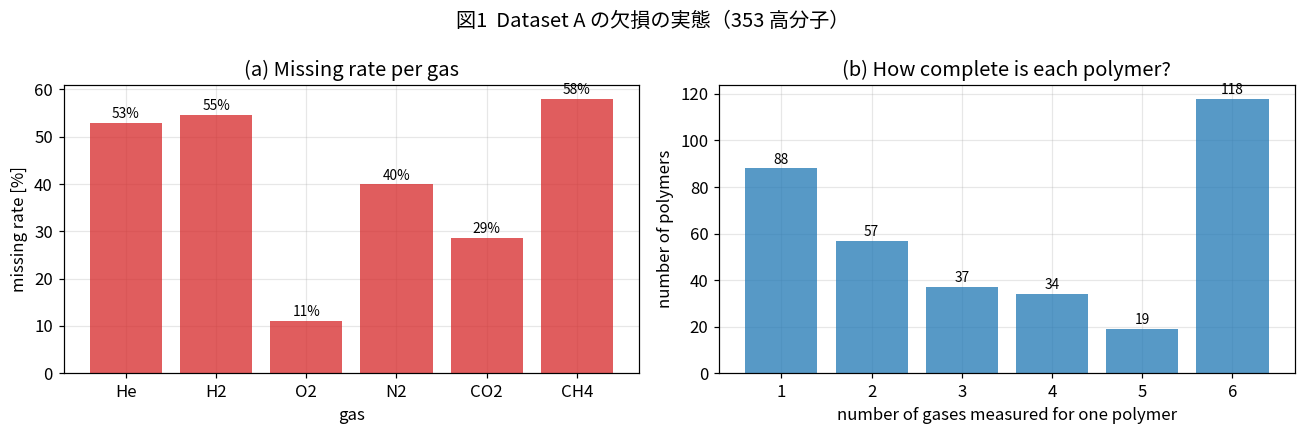

6ガスすべてが実測されている高分子: 118 / 353


In [6]:
measured = get_measured_targets(dataset_a)
n_gases_measured = measured.notna().sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(missing_summary['gas'], missing_summary['missing_rate'] * 100, color='tab:red', alpha=0.75)
axes[0].set_ylabel('missing rate [%]')
axes[0].set_xlabel('gas')
axes[0].set_title('(a) Missing rate per gas')
for x, value in enumerate(missing_summary['missing_rate'] * 100):
    axes[0].text(x, value + 1, f'{value:.0f}%', ha='center', fontsize=9)

counts = n_gases_measured.value_counts().sort_index()
axes[1].bar(counts.index, counts.values, color='tab:blue', alpha=0.75)
axes[1].set_xlabel('number of gases measured for one polymer')
axes[1].set_ylabel('number of polymers')
axes[1].set_title('(b) How complete is each polymer?')
for x, value in zip(counts.index, counts.values):
    axes[1].text(x, value + 2, str(value), ha='center', fontsize=9)

fig.suptitle('図1  Dataset A の欠損の実態（353 高分子）')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig01_missingness.png')
plt.show()

print(f"6ガスすべてが実測されている高分子: {(n_gases_measured == 6).sum()} / {len(dataset_a)}")

図1(a) を見ると、最もよく測られている O₂ ですら 11% が欠測、CH₄ に至っては 58% が欠測です。図1(b) のとおり、6ガス全部が揃っているのは 353 種のうち 118 種（**約3分の1**）にすぎません。

**ここが本研究の最初の技術的な山場です。** 素直に「6ガスすべて揃っている高分子だけ」で学習すると、学習データが3分の1に減ってしまいます。しかも捨てられるのは「O₂ だけ測った古い文献」に偏るため、単にデータが減るだけでなく偏りも生じます。論文は代わりに、

1. 欠損値を統計的に**補完（imputation）**して穴を埋め、
2. 6ガスを**同時に予測するマルチタスクモデル**を学習する

という方針を採りました。ガス同士の透過係数には強い相関があるので、「O₂ しか測っていない高分子」からも N₂ の予測に役立つ情報が引き出せる、という発想です。第3回で実際に確かめます。

### 2.2 透過係数はどんな分布をしているか

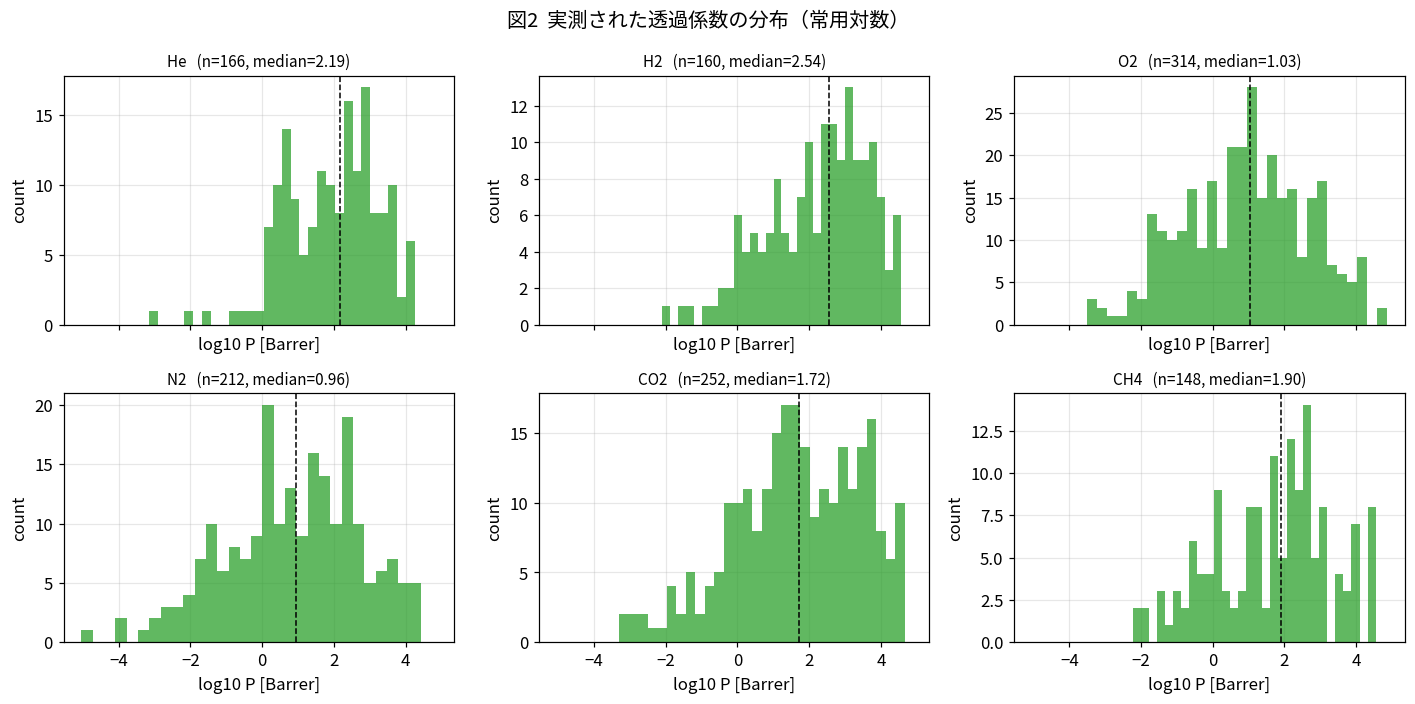

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5), sharex=True)

for ax, gas in zip(axes.ravel(), GAS_NAMES):
    values = measured[f'log10_{gas}'].dropna()
    ax.hist(values, bins=30, color='tab:green', alpha=0.75)
    ax.axvline(values.median(), color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{gas}   (n={len(values)}, median={values.median():.2f})', fontsize=10)
    ax.set_xlabel('log10 P [Barrer]')
    ax.set_ylabel('count')

fig.suptitle('図2  実測された透過係数の分布（常用対数）')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig02_permeability_distribution.png')
plt.show()

透過係数は10⁻⁵ から 10⁵ Barrer まで**10桁**にわたって分布しています。このような量をそのまま扱うと、大きい値だけに引きずられたモデルになってしまうため、論文は一貫して $\log_{10} P$ を予測対象としています。

次に、ガス同士がどれくらい相関しているかを見ます。マルチタスク学習が有効かどうかの根拠になります。

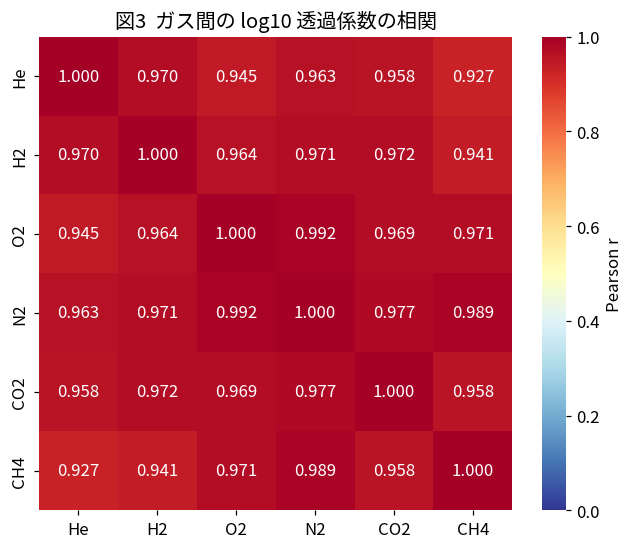

ガス間相関の最小値: 0.927 (('He', 'CH4'))
ガス間相関の最大値: 0.992 (('O2', 'N2'))


In [8]:
correlation = measured.corr()  # 欠損は pairwise に除外される
correlation.index = GAS_NAMES
correlation.columns = GAS_NAMES

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(correlation, annot=True, fmt='.3f', cmap='RdYlBu_r', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('図3  ガス間の log10 透過係数の相関')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig03_gas_correlation.png')
plt.show()

pairs = [(a, b) for i, a in enumerate(GAS_NAMES) for b in GAS_NAMES[i + 1:]]
values = [correlation.loc[a, b] for a, b in pairs]
print(f"ガス間相関の最小値: {min(values):.3f} ({pairs[int(np.argmin(values))]})")
print(f"ガス間相関の最大値: {max(values):.3f} ({pairs[int(np.argmax(values))]})")

**相関係数はどのペアでも 0.9 前後**です。これは物理的にも自然で、自由体積が大きく鎖が動きやすい高分子は、どのガスもよく通します。

この強い相関があるからこそ、

- 欠損値の補完が現実的に機能する（他のガスの値から推定できる）
- マルチタスク学習で6ガスの予測性能が同時に上がる（共通の中間表現を学べる）

という2つの設計判断が成り立ちます。

---
## 3. Robesonプロットを描く（論文 Fig.2 の再現）

透過係数と選択性の関係を見てみましょう。x軸は速いガスの透過係数、y軸は速いガス/遅いガスの選択性で、どちらも常用対数です。黒い線が Robeson 上限です。

In [9]:
# 上限線の係数を確認する（原著 visualizations.ipynb の値をそのまま使用）
bound_table = []
for name, config in SEPARATIONS.items():
    for year, (log_beta, slope) in sorted(config['bounds'].items()):
        bound_table.append({'separation': name, 'year': year,
                            'log10_beta': round(log_beta, 4), 'slope_n': round(slope, 4)})
pd.DataFrame(bound_table)

,separation,year,log10_beta,slope_n
0,O2/N2,1991,0.9638,0.1724
1,O2/N2,2008,1.0845,0.1765
2,O2/N2,2015,1.2672,0.1754
3,CO2/CH4,1991,2.2962,0.3807
4,CO2/CH4,2008,2.5531,0.3794
5,CO2/CH4,2019,3.0628,0.4165
6,CO2/N2,2008,2.5938,0.3463
7,CO2/N2,2019,2.6044,0.2933
8,H2/CO2,1991,1.5902,0.5164
9,H2/CO2,2008,1.5876,0.4344


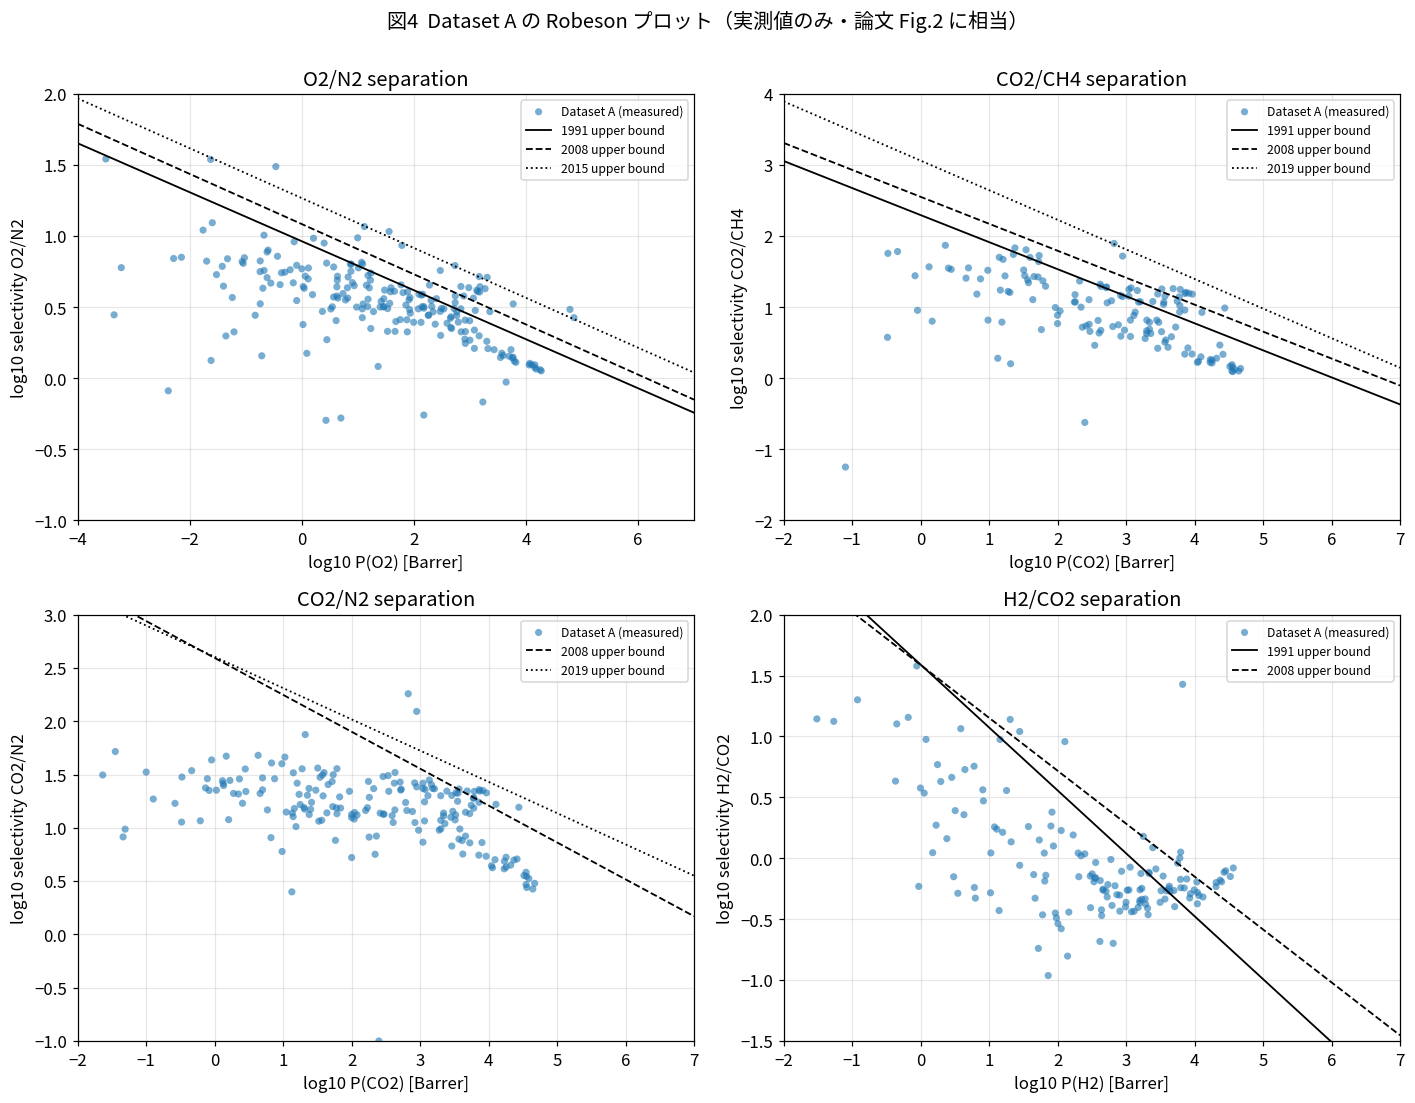

In [10]:
# 実測値のみ（欠損があるペアは自動的に除外される）
measured_array = measured.to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
from module.pgm_robeson import plot_robeson_panel

for ax, separation in zip(axes.ravel(), SEPARATIONS):
    plot_robeson_panel(ax, measured_array, separation,
                       label='Dataset A (measured)', color='tab:blue', s=22, alpha=0.6)
    ax.legend(fontsize=8, loc='upper right')

fig.suptitle('図4  Dataset A の Robeson プロット（実測値のみ・論文 Fig.2 に相当）', y=1.00)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig04_robeson_measured.png')
plt.show()

右下がりの黒線が Robeson 上限で、線種は実線=1991年、破線=2008年、点線=2015/2019年です。点群がきれいに線の左下側に収まり、少数の材料だけが線の上に顔を出しているのが見て取れます。線の上にいるものの多くが **PIM（polymers of intrinsic microporosity, 自己微多孔性高分子）** です。

In [11]:
# 補完済みの値（BLR）で数えると、上限を超えている高分子は何種類か
targets_blr = get_targets(dataset_a, 'BLR').to_numpy()
above = count_above_bound(targets_blr, year=2008)
above['n_total'] = len(targets_blr)
above

,separation,n_above_2008,fraction,max_distance,n_total
0,O2/N2,21,0.059490,0.244406,353
1,CO2/CH4,15,0.042493,0.415799,353
2,CO2/N2,13,0.036827,0.642629,353
3,H2/CO2,26,0.073654,0.584612,353


353種のうち2008年上限を超えるのは各分離で 13〜26 種程度です。**この少数の「上限超え」材料を、化学構造だけからもっとたくさん見つけたい**というのが本研究の狙いです。第5回では、学習したモデルで900万個の仮想高分子を評価し、数万個の上限超え候補を得るところまで進みます。

---
## 4. スクリーニング用データセット B・C・D

論文は学習用の Dataset A に加えて、**透過係数が未知で構造だけが分かっている**仮想高分子のデータセットを3つ用意しています（論文 Table 1）。

In [12]:
dataset_d = load_screening_smiles(DATA_DIR, 'datasetD')
dataset_b_head = load_screening_smiles(DATA_DIR, 'datasetB', n_rows=5)
dataset_c_head = load_screening_smiles(DATA_DIR, 'datasetC_0', n_rows=5)

overview = pd.DataFrame([
    {'dataset': 'A', 'n_polymers': 778, 'n_unique': 353, 'permeability': '実測（一部欠損）',
     'description': '学習用。PoLyInfo + MSA データベース'},
    {'dataset': 'B', 'n_polymers': 995_799, 'n_unique': 995_799, 'permeability': '未知',
     'description': 'PI1M。PoLyInfo で学習した RNN が生成した仮想高分子'},
    {'dataset': 'C', 'n_polymers': 8_205_087, 'n_unique': 8_205_087, 'permeability': '未知',
     'description': 'PubChem の既知ジアミン/ジイソシアネート x 酸二無水物から作る仮想ポリイミド'},
    {'dataset': 'D', 'n_polymers': 1_124, 'n_unique': 1_124, 'permeability': '未知',
     'description': '既存のラダーポリマーの部品の組み合わせ + RNN'},
])
overview

,dataset,n_polymers,n_unique,permeability,description
0,A,778,353,実測（一部欠損）,学習用。PoLyInfo + MSA データベース
1,B,995799,995799,未知,PI1M。PoLyInfo で学習した RNN が生成した仮想高分子
2,C,8205087,8205087,未知,PubChem の既知ジアミン/ジイソシアネート x 酸二無水物から作る仮想ポリイミド
3,D,1124,1124,未知,既存のラダーポリマーの部品の組み合わせ + RNN


In [13]:
print('--- Dataset D（ラダーポリマー）の例 ---')
for smiles in dataset_d['Smiles'].head(3):
    print(smiles)
print()
print('--- Dataset B（PI1M）の例 ---')
for smiles in dataset_b_head['Smiles'].head(3):
    print(smiles)
print()
print('--- Dataset C（仮想ポリイミド）の例 ---')
for smiles in dataset_c_head['Smiles'].head(3):
    print(smiles)
print()
print(f"同梱ファイル: datasetD.csv = {len(dataset_d)} 行（Dataset D 全件）")
print("datasetB.csv = 995,799 行（全件）、datasetC_0.csv = 8,205,087 行のうち先頭 100 万行")

--- Dataset D（ラダーポリマー）の例 ---
*Oc1cc2c(cc1O*)C1(c3cc4c(cc3C(C)(CC)C1C)Oc1c(C#N)c(*)c(*)c(C#N)c1O4)C(C)C2(C)CC
*Oc1cc2c(cc1O*)C1(c3cc4c(cc3C(C)(CC)C1C)Oc1cc3c(cc1O4)C(=O)N(c1c(C)c(C)c(N4C(=O)c5cc(*)c(*)cc5C4=O)c(C)c1C)C3=O)C(C)C2(C)CC
*Oc1cc2c(cc1O*)C1(c3cc4c(cc3C(C)(CC)C1C)Oc1cc3c(cc1O4)C(=O)N(c1c(C)cc(C)c(N4C(=O)c5cc(*)c(*)cc5C4=O)c1C)C3=O)C(C)C2(C)CC

--- Dataset B（PI1M）の例 ---
*CCC[Fe]CCCC(=O)OCCCCOCCCNCC(*)=O
*CCCC1C=CNC2=CC=C2C(*)CCC1
*CCC*

--- Dataset C（仮想ポリイミド）の例 ---
*c1cccc(N2C(=O)C3C4C(=O)N(*)C(=O)C4C3C2=O)c1C
*c1cccc(N2C(=O)c3ccc4c5c(ccc(c35)C2=O)C(=O)N(*)C4=O)c1C
*c1cccc(N2C(=O)c3ccc(C(=O)c4ccc5c(c4)C(=O)N(*)C5=O)cc3C2=O)c1C

同梱ファイル: datasetD.csv = 1124 行（Dataset D 全件）
datasetB.csv = 995,799 行（全件）、datasetC_0.csv = 8,205,087 行のうち先頭 100 万行


3つのデータセットは、それぞれ**狙って違う化学空間**を張っています。

- **Dataset B（PI1M）**：既存高分子に「似ている」ものが中心。膜用に設計されたものではないので、透過性・選択性ともに低めの予測になるはず
- **Dataset C（仮想ポリイミド）**：ポリイミドは剛直な芳香族主鎖のおかげで透過性と選択性のバランスが良く、化学的・物理的安定性も高い。PoLyInfo に約2000種しかないポリイミドを800万種に拡張した
- **Dataset D（ラダーポリマー）**：繰り返し単位間が2本の結合でつながり、スピロ中心以外では回転できない。PIM の代表格

このように「探索空間そのものを設計する」ことが、機械学習による材料探索では効いてきます。なお Dataset D の構造をよく見ると、`*Oc1cc2c(cc1O*)C1(...)...` のように`*`（結合点）が4つあるのが分かります。これがラダーポリマーの特徴です。

In [14]:
n_connection_points = dataset_d['Smiles'].str.count(r'\*')
print('Dataset D の結合点(*)の数の内訳:')
print(n_connection_points.value_counts().sort_index().to_string())
print()
n_connection_points_b = dataset_b_head['Smiles'].str.count(r'\*')
print('（比較）Dataset B の先頭5件の結合点の数:', n_connection_points_b.tolist())

Dataset D の結合点(*)の数の内訳:
Smiles
2       1
3      21
4    1096
5       5
6       1

（比較）Dataset B の先頭5件の結合点の数: [2, 2, 2, 2, 2]


---
## 5. まとめと比較

### 5.1 データセットの比較表

In [15]:
comparison = pd.DataFrame({
    'Dataset A (train)': {
        'n_polymers': 353,
        'permeability': 'known (with gaps)',
        'chemical space': 'existing polymers (PoLyInfo + MSA)',
        'role': 'model training',
    },
    'Dataset B': {
        'n_polymers': 995_799,
        'permeability': 'unknown',
        'chemical space': 'PoLyInfo-like (RNN generated)',
        'role': 'screening',
    },
    'Dataset C': {
        'n_polymers': 8_205_087,
        'permeability': 'unknown',
        'chemical space': 'hypothetical polyimides',
        'role': 'screening',
    },
    'Dataset D': {
        'n_polymers': 1_124,
        'permeability': 'unknown',
        'chemical space': 'ladder polymers (PIMs)',
        'role': 'screening',
    },
}).T
comparison.to_csv(OUTPUT_DIR / 'dataset_overview.csv')
comparison

,n_polymers,permeability,chemical space,role
Dataset A (train),353,known (with gaps),existing polymers (PoLyInfo + MSA),model training
Dataset B,995799,unknown,PoLyInfo-like (RNN generated),screening
Dataset C,8205087,unknown,hypothetical polyimides,screening
Dataset D,1124,unknown,ladder polymers (PIMs),screening


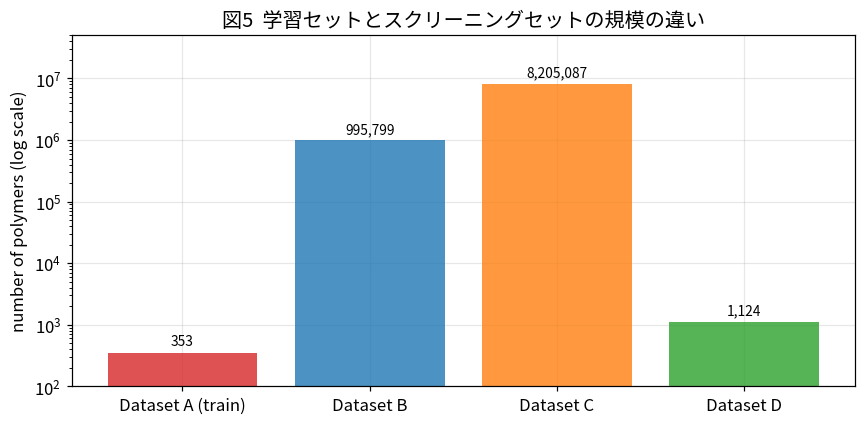

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
labels = list(comparison.index)
sizes = comparison['n_polymers'].astype(float).values
bars = ax.bar(labels, sizes, color=['tab:red', 'tab:blue', 'tab:orange', 'tab:green'], alpha=0.8)
ax.set_yscale('log')
ax.set_ylabel('number of polymers (log scale)')
ax.set_title('図5  学習セットとスクリーニングセットの規模の違い')
for bar, size in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width() / 2, size * 1.3, f'{int(size):,}', ha='center', fontsize=9)
ax.set_ylim(100, 5e7)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig05_dataset_sizes.png')
plt.show()

図5が本研究の構図を端的に表しています。**353種の実測データで学習し、900万種を評価する。**学習データの2万倍以上の空間へ外挿することになるので、「モデルが本当に汎化しているか」の検証が決定的に重要になります（第3回・第5回で扱います）。

### 5.2 本ノートブックのまとめ

1. ガス分離膜の性能は**透過係数 $P$** と**選択性 $\alpha = P_A/P_B$** で測り、両者にはトレードオフ（**Robeson上限**）がある
2. 学習データ Dataset A は 353 種の高分子。ただし**ガスによって11〜58%が欠測**しており、6ガス全部が揃っている高分子はごく少数
3. ガス間の透過係数は**相関係数0.9前後**と強く相関している。これが欠損値補完とマルチタスク学習という設計判断の根拠になる
4. スクリーニング対象の Dataset B/C/D は、それぞれ狙いを持って設計された化学空間である

### 5.3 本ノートブックで扱っていないこと

- **透過係数の測定方法**：定圧法・定容法などの実験手法や、測定条件（温度・圧力）の影響。Dataset A は条件の違う文献値を混ぜて平均しており、これはモデルの誤差要因になりうる
- **PoLyInfo / MSA データベースの詳細**：収録範囲やデータ品質。Dataset A は著者らが手作業で収集・整理したもので、その過程は論文の Supplementary に記載されている
- **経年劣化・可塑化・膨潤**：実際の膜は使用中に性能が落ちるが、本研究のモデルは性能を時間に依らない定数として扱っている（論文 Discussion で限界として言及されている）
- **Dataset B/C/D の生成手法そのもの**：RNN による高分子生成や、ポリイミドの組み合わせ生成の詳細

---
## 6. 演習問題

**問1.** `dataset_a_raw` の `Year` 列を使い、1990年以前と2005年以降でO₂ 透過係数（`log10_O2`）の分布がどう違うか比べてください。論文は「新しい MSA データベースの方が透過係数の高い高分子を含む」と述べています。確かめられますか。

**問2.** `count_above_bound()` を `year=1991` に変えて実行し、2008年上限の場合と上限超えの件数を比べてください。なぜ差が出るのか説明してください。

**問3.** 図3の相関行列で、He と CH₄ の相関が相対的に低い理由を、分子径と溶解拡散モデルの観点から考察してください。

**問4.** Dataset A で「6ガスすべてが実測されている高分子」だけを取り出し、その件数でモデルを学習するとしたらどんな問題が起きるか、3つ挙げてください。

**問5（発展）.** Robeson 上限の式 $\log\alpha = \log\beta - n\log P$ において、傾き $n$ が分離ペアごとに違います（O₂/N₂ で約0.18、CO₂/CH₄ で約0.38）。この傾きの物理的な意味は何でしょうか。文献 Robeson (2008) *J. Membr. Sci.* 320, 390 を参照して調べてみてください。

---
### 次回予告

第2回では、`*C*` のような SMILES 文字列を機械学習が扱える**数値ベクトル**に変換します。RDKit の分子記述子と Morgan フィンガープリント（MFF）の2通りを実装し、同梱の `datasetAX_fing.csv` をビット単位で再現できることを確認します。

### 参考文献

1. J. Yang, L. Tao, J. He, J. R. McCutcheon, Y. Li, *Sci. Adv.* **8**, eabn9545 (2022). DOI: 10.1126/sciadv.abn9545
2. L. M. Robeson, "The upper bound revisited", *J. Membr. Sci.* **320**, 390-400 (2008). DOI: 10.1016/j.memsci.2008.04.030
3. Q. Yuan et al., "Imputation of missing gas permeability data for polymer membranes using machine learning", *J. Membr. Sci.* **627**, 119207 (2021). DOI: 10.1016/j.memsci.2021.119207
4. S. Ma, R. Luo, "PI1M: A benchmark database for polymer informatics", *J. Chem. Inf. Model.* **60**, 4684-4690 (2020). DOI: 10.1021/acs.jcim.0c00726